# Eksplorasi Analisis & Prediksi Harga Pangan Hybrid ARIMA + Random Forest
Notebook ini berisi alur lengkap proses analisis deret waktu (*time series*) dan pembuatan model prediksi hybrid ARIMA dan Random Forest untuk data harga pangan nasional berdasarkan data dari Bank Indonesia.

### Alur Pengerjaan:
1. **Data Collecting**: Mengambil data harga dari API Bank Indonesia untuk 10 kategori komoditas pangan dengan retry logic dan local caching.
2. **Exploratory Data Analysis (EDA)**: Menganalisis karakteristik data secara visual dan statistik.
3. **Data Preprocessing**: Melakukan imputasi nilai yang hilang, konversi format data, dan pembuatan fitur-fitur lag & rolling.
4. **Model Training (Hybrid ARIMA + Random Forest)**: Melatih model ARIMA untuk menangkap pola linear, dilanjutkan model Random Forest untuk memprediksi sisa kesalahan (residual).
5. **Model Evaluation**: Mengevaluasi hasil prediksi menggunakan metrik visual dan statistik (MAE, RMSE, MAPE, R2).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import urllib3
import time
import os
from datetime import datetime, timedelta
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

# Menyembunyikan warning SSL & Deprecation
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
warnings.filterwarnings('ignore')

# Pengaturan visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

## 1. Data Collecting
Kami mengunduh data harian dari portal Pusat Informasi Harga Pangan Strategis (PIHPS) Bank Indonesia untuk 10 kategori bahan pokok berikut:
- `cat_1` (Beras)
- `cat_2` (Daging Ayam)
- `cat_3` (Daging Sapi)
- `cat_4` (Telur Ayam)
- `cat_5` (Bawang Merah)
- `cat_6` (Bawang Putih)
- `cat_7` (Cabai Merah)
- `cat_8` (Cabai Rawit)
- `cat_9` (Minyak Goreng)
- `cat_10` (Gula Pasir)

Rentang waktu yang digunakan adalah 1 tahun terakhir (2025-05-22 hingga 2026-05-22). Untuk menjamin keandalan sistem, diimplementasikan mekanisme **retry logic** dengan *exponential backoff* dan **local caching** menggunakan file CSV.

In [2]:
# List kategori komoditas berdasarkan request
categories = {
    "cat_1": "Beras",
    "cat_2": "Daging Ayam",
    "cat_3": "Daging Sapi",
    "cat_4": "Telur Ayam",
    "cat_5": "Bawang Merah",
    "cat_6": "Bawang Putih",
    "cat_7": "Cabai Merah",
    "cat_8": "Cabai Rawit",
    "cat_9": "Minyak Goreng",
    "cat_10": "Gula Pasir"
}

start_date = "2025-05-22"
end_date = "2026-05-22"
url = "https://www.bi.go.id/hargapangan/WebSite/TabelHarga/GetGridDataDaerah"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

cache_file = "raw_market_prices_cache.csv"

def fetch_category_data(cat_id, cat_name, max_retries=3, backoff=2):
    params = {
        "price_type_id": 1,
        "comcat_id": cat_id,
        "province_id": "",
        "regency_id": "",
        "market_id": "",
        "tipe_laporan": 1,
        "start_date": start_date,
        "end_date": end_date,
        "_": 1779434760544
    }
    for attempt in range(max_retries):
        try:
            response = requests.get(url, params=params, headers=headers, verify=False, timeout=20)
            if response.status_code == 200:
                res_json = response.json()
                if "data" in res_json and len(res_json["data"]) > 0:
                    return res_json["data"]
            print(f"[Percobaan {attempt+1}] Gagal mengunduh {cat_name} (Status: {response.status_code}). Mengulang...")
        except Exception as e:
            print(f"[Percobaan {attempt+1}] Gagal mengunduh {cat_name} karena error: {e}. Mengulang...")
        time.sleep(backoff ** attempt)
    return None

if os.path.exists(cache_file):
    print(f"Menemukan file cache lokal '{cache_file}'. Membaca data cache...")
    df_raw = pd.read_csv(cache_file)
else:
    raw_data_list = []
    print("Mulai proses crawling data dari API Bank Indonesia...")
    for cat_id, cat_name in categories.items():
        data = fetch_category_data(cat_id, cat_name)
        if data:
            found = False
            for item in data:
                if item.get("no") == "I" and item.get("level") == 1:
                    row_dict = {"Category": cat_name, "Subcategory": item.get("name")}
                    for key, value in item.items():
                        if "/" in key and len(key.split("/")) == 3:
                            row_dict[key] = value
                    raw_data_list.append(row_dict)
                    print(f"Berhasil mengunduh data untuk: {cat_name} ({item.get('name')})")
                    found = True
                    break
            if not found:
                print(f"PERINGATAN: Tidak ada data matching (no='I', level=1) untuk {cat_name}.")
        else:
            print(f"PERINGATAN: Kategori {cat_name} gagal diunduh setelah beberapa percobaan.")

    df_raw = pd.DataFrame(raw_data_list)
    if not df_raw.empty:
        df_raw.to_csv(cache_file, index=False)
        print(f"Sukses menyimpan data baru ke cache file '{cache_file}'.")
    else:
        raise ValueError("Gagal memperoleh data dari API maupun Cache. Periksa koneksi internet Anda.")

print("\nDimensi data mentah:", df_raw.shape)
df_raw.head()

Mulai proses crawling data dari API Bank Indonesia...
Berhasil mengunduh data untuk: Beras (Beras)
Berhasil mengunduh data untuk: Daging Ayam (Daging Ayam)
Berhasil mengunduh data untuk: Daging Sapi (Daging Sapi)
Berhasil mengunduh data untuk: Telur Ayam (Telur Ayam)
Berhasil mengunduh data untuk: Bawang Merah (Bawang Merah)
Berhasil mengunduh data untuk: Bawang Putih (Bawang Putih)
Berhasil mengunduh data untuk: Cabai Merah (Cabai Merah)
Berhasil mengunduh data untuk: Cabai Rawit (Cabai Rawit)
Berhasil mengunduh data untuk: Minyak Goreng (Minyak Goreng)
Berhasil mengunduh data untuk: Gula Pasir (Gula Pasir)
Sukses menyimpan data baru ke cache file 'raw_market_prices_cache.csv'.

Dimensi data mentah: (10, 264)


,Category,Subcategory,22/05/2025,23/05/2025,26/05/2025,27/05/2025,28/05/2025,29/05/2025,30/05/2025,02/06/2025,...,11/05/2026,12/05/2026,13/05/2026,14/05/2026,15/05/2026,18/05/2026,19/05/2026,20/05/2026,21/05/2026,22/05/2026
0,Beras,Beras,"15,400","15,400","15,400","15,400","15,400","15,400","15,400","15,450",...,"15,950","15,950","15,950","16,000","16,000","16,000","16,000","16,000","16,000","16,000"
1,Daging Ayam,Daging Ayam,"35,950","35,850","35,600","35,600","35,600","35,600","35,650","35,800",...,"38,700","38,700","38,600","38,700","38,750","38,650","38,550","38,400","38,600","38,500"
2,Daging Sapi,Daging Sapi,"136,600","136,600","136,600","136,600","136,600","136,450","136,300","136,600",...,"144,250","144,200","144,200","144,150","144,200","144,400","144,400","144,550","144,700","144,800"
3,Telur Ayam,Telur Ayam,"29,850","29,850","29,800","29,750","29,700","29,750","29,700","29,750",...,"31,000","30,900","30,900","30,950","30,950","30,600","30,550","30,500","30,550","30,500"
4,Bawang Merah,Bawang Merah,"41,050","40,900","40,600","40,500","40,650","40,650","40,500","41,000",...,"47,000","47,150","47,250","47,350","47,400","47,500","47,650","47,950","48,100","48,350"


## 2. Exploratory Data Analysis (EDA)
Pada bagian ini, kita akan:
1. Mengubah bentuk data mentah (wide format) menjadi format panjang (long format/tidy data) agar mudah dianalisis dan dimodelkan.
2. Membersihkan nilai harga pangan (menghilangkan tanda koma pemisah ribuan dan mengonversi ke tipe data numerik).
3. Memvisualisasikan tren harga dari 10 komoditas pangan untuk melihat pergerakannya selama 1 tahun terakhir.
4. Melakukan uji stasioneritas menggunakan **Augmented Dickey-Fuller (ADF) Test** untuk salah satu komoditas utama (Beras).

In [3]:
# Transformasi dari Wide ke Long format
long_data = []

for idx, row in df_raw.iterrows():
    category = row["Category"]
    subcategory = row["Subcategory"]

    for col in df_raw.columns:
        if "/" in col:
            val_str = str(row[col]).strip()
            if val_str and val_str not in ["-", "null", "None", "nan"]:
                try:
                    price = float(val_str.replace(",", ""))
                    date_val = datetime.strptime(col, "%d/%m/%Y").date()
                    long_data.append({
                        "Date": date_val,
                        "Category": category,
                        "Subcategory": subcategory,
                        "Price": price
                    })
                except ValueError:
                    pass

df_tidy = pd.DataFrame(long_data)
df_tidy["Date"] = pd.to_datetime(df_tidy["Date"])
df_tidy = df_tidy.sort_values(by=["Category", "Date"]).reset_index(drop=True)

print("Dimensi data bersih:", df_tidy.shape)
print("\nStatistik Deskriptif Kategori:")
print(df_tidy.groupby("Category")["Price"].describe())

Dimensi data bersih: (2620, 4)

Statistik Deskriptif Kategori:
               count           mean           std       min       25%  \
Category                                                                
Bawang Merah   262.0   46495.610687   4345.607044   40250.0   43300.0   
Bawang Putih   262.0   40254.389313   1118.123860   38600.0   39400.0   
Beras          262.0   15801.908397    137.284081   15400.0   15750.0   
Cabai Merah    262.0   50460.687023   5899.217455   39050.0   46075.0   
Cabai Rawit    262.0   57350.763359  10015.968065   38800.0   49150.0   
Daging Ayam    262.0   38925.954198   2392.808119   34850.0   36550.0   
Daging Sapi    262.0  139331.679389   3079.043030  136300.0  137000.0   
Gula Pasir     262.0   19063.740458    265.121488   18750.0   18850.0   
Minyak Goreng  262.0   21293.702290    507.178767   20900.0   21000.0   
Telur Ayam     262.0   31416.793893   1103.870076   29700.0   30400.0   

                    50%       75%       max  
Category      

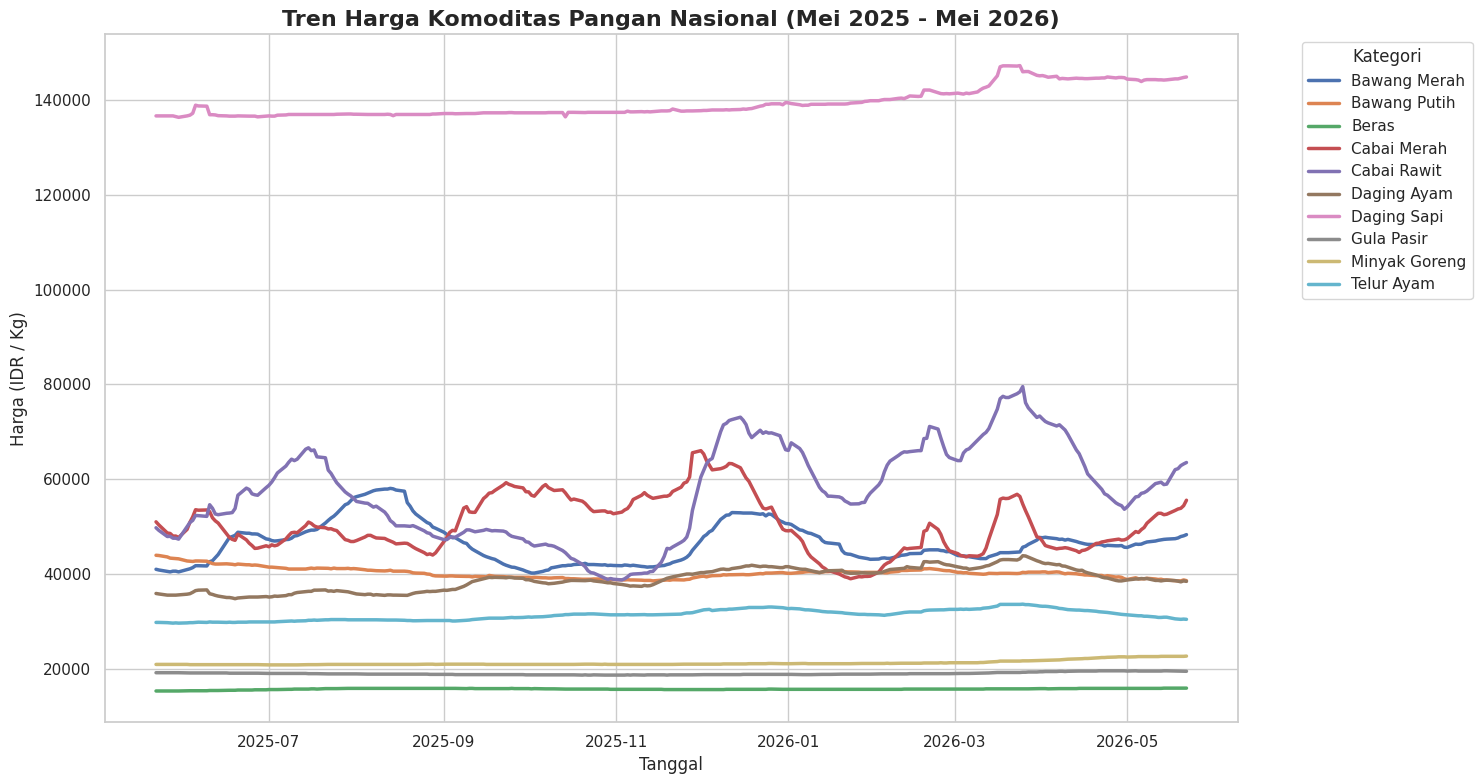

In [4]:
# Plot tren harga untuk seluruh kategori komoditas
plt.figure(figsize=(15, 8))
sns.lineplot(data=df_tidy, x="Date", y="Price", hue="Category", linewidth=2.5)
plt.title("Tren Harga Komoditas Pangan Nasional (Mei 2025 - Mei 2026)", fontsize=16, fontweight='bold')
plt.xlabel("Tanggal", fontsize=12)
plt.ylabel("Harga (IDR / Kg)", fontsize=12)
plt.legend(title="Kategori", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [5]:
# Ambil data Beras sebagai fokus analisis
df_beras = df_tidy[df_tidy["Category"] == "Beras"].copy()

if df_beras.empty:
    print("PERINGATAN: Kategori Beras tidak ditemukan di data, menggunakan kategori pertama yang tersedia.")
    first_cat = df_tidy["Category"].unique()[0]
    df_beras = df_tidy[df_tidy["Category"] == first_cat].copy()

df_beras = df_beras.set_index("Date").asfreq('D')

# Imputasi nilai kosong (akhir pekan / libur nasional) dengan linear interpolation & ffill/bfill
df_beras["Price"] = df_beras["Price"].interpolate(method='linear').ffill().bfill()

# Uji Dickey-Fuller Stasioneritas
print(f"Melakukan Augmented Dickey-Fuller (ADF) Test untuk Harga {df_beras['Category'].iloc[0]}:")
result = adfuller(df_beras["Price"])
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"\t{key}: {value:.4f}")

if result[1] < 0.05:
    print("Hasil: Data stasioner (p-value < 0.05)")
else:
    print("Hasil: Data TIDAK stasioner (p-value >= 0.05). Diperlukan differencing untuk model ARIMA.")

Melakukan Augmented Dickey-Fuller (ADF) Test untuk Harga Beras:
ADF Statistic: -2.6900
p-value: 0.0758
Critical Values:
	1%: -3.4489
	5%: -2.8697
	10%: -2.5711
Hasil: Data TIDAK stasioner (p-value >= 0.05). Diperlukan differencing untuk model ARIMA.


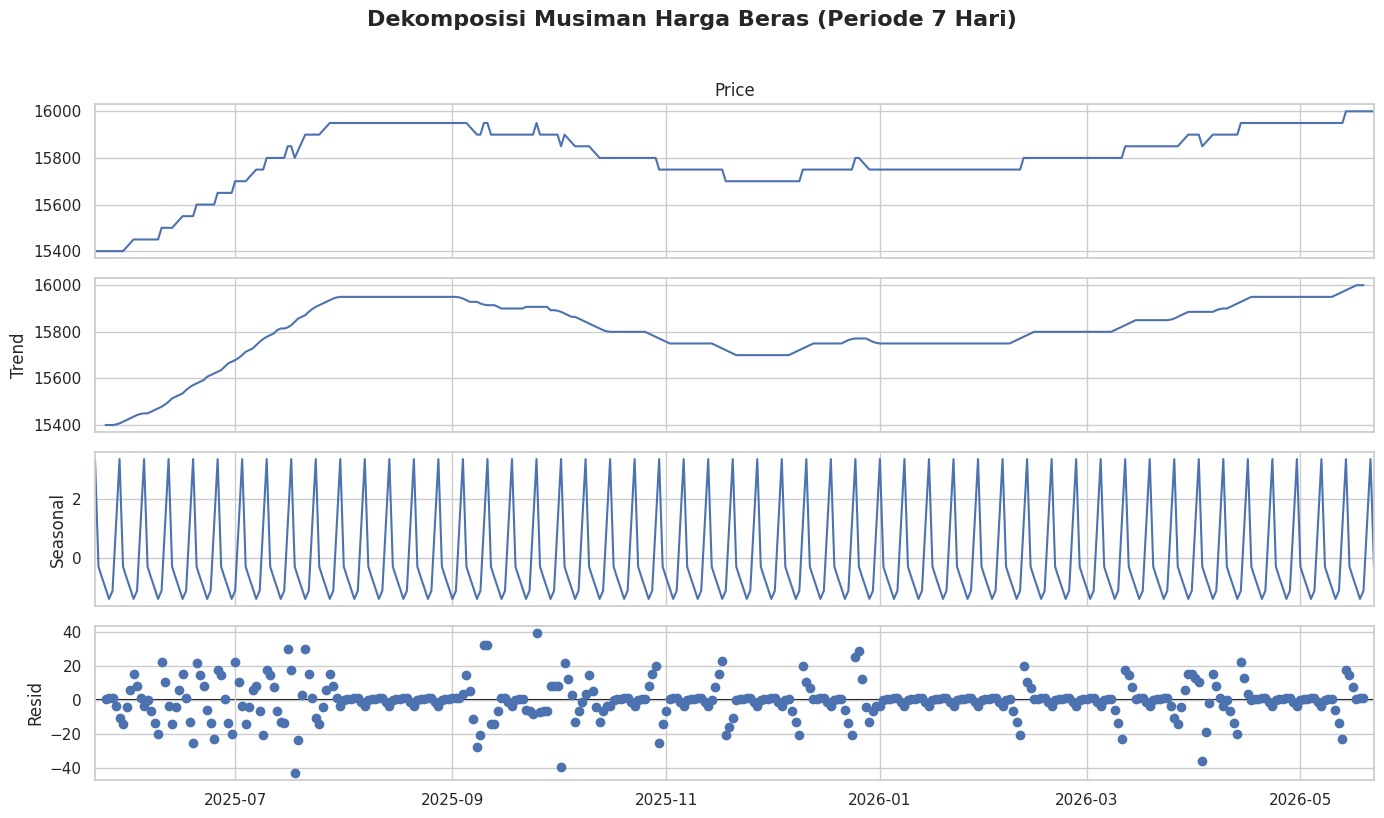

In [6]:
# Dekomposisi Musiman Harga Beras
decomposition = seasonal_decompose(df_beras["Price"], model='additive', period=7)
fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.suptitle(f"Dekomposisi Musiman Harga {df_beras['Category'].iloc[0]} (Periode 7 Hari)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Data Preprocessing & Feature Engineering
Langkah-langkah yang dilakukan:
1. **Feature Engineering** untuk model Random Forest:
   - **Fitur Kalender**: `day_of_week`, `day_of_month`, `day_of_year`, `month`, `year`, `is_weekend`.
   - **Fitur Lag**: Nilai harga pada $t-1$, $t-2$, dan $t-7$.
   - **Fitur Rolling**: Rata-rata bergulir dan standar deviasi harga selama 7 hari terakhir (menggunakan data historis agar tidak terjadi data leakage).
2. **Pemisahan Data**: Membagi data secara kronologis (temporal split) menjadi 80% data latih (train) dan 20% data uji (test).

In [7]:
def preprocess_series(df_series):
    df = df_series.copy()
    df = df.asfreq('D')
    df["Price"] = df["Price"].interpolate(method='linear').ffill().bfill()

    # Fitur Kalender
    df["day_of_week"] = df.index.dayofweek
    df["day_of_month"] = df.index.day
    df["day_of_year"] = df.index.dayofyear
    df["month"] = df.index.month
    df["year"] = df.index.year
    df["is_weekend"] = df["day_of_week"].apply(lambda x: 1 if x >= 5 else 0)

    # Fitur Lag
    df["lag_1"] = df["Price"].shift(1)
    df["lag_2"] = df["Price"].shift(2)
    df["lag_7"] = df["Price"].shift(7)

    # Fitur Rolling (berdasarkan lag_1 untuk mencegah leakage)
    df["rolling_mean_7"] = df["lag_1"].rolling(window=7).mean()
    df["rolling_std_7"] = df["lag_1"].rolling(window=7).std()

    df = df.dropna()
    return df

df_prep = preprocess_series(df_beras)
print("Dimensi data setelah preprocessing:", df_prep.shape)
df_prep.head()

Dimensi data setelah preprocessing: (257, 14)


,Category,Subcategory,Price,day_of_week,day_of_month,day_of_year,month,year,is_weekend,lag_1,lag_2,lag_7,rolling_mean_7,rolling_std_7
Date,,,,,,,,,,,,,,
2025-05-29,Beras,Beras,15400.0,3,29,149,5,2025,0,15400.000000,15400.000000,15400.0,15400.000000,0.000000
2025-05-30,Beras,Beras,15400.0,4,30,150,5,2025,0,15400.000000,15400.000000,15400.0,15400.000000,0.000000
2025-06-02,Beras,Beras,15450.0,0,2,153,6,2025,0,15433.333333,15416.666667,15400.0,15407.142857,13.113263
2025-06-03,Beras,Beras,15450.0,1,3,154,6,2025,0,15450.000000,15433.333333,15400.0,15414.285714,20.249763
2025-06-04,Beras,Beras,15450.0,2,4,155,6,2025,0,15450.000000,15450.000000,15400.0,15421.428571,23.002185


In [8]:
# Pembagian data secara temporal (80% Train, 20% Test)
split_idx = int(len(df_prep) * 0.8)

df_train = df_prep.iloc[:split_idx].copy()
df_test = df_prep.iloc[split_idx:].copy()

print(f"Data Latih (Train): {df_train.index.min()} s/d {df_train.index.max()} ({len(df_train)} sampel)")
print(f"Data Uji (Test):   {df_test.index.min()} s/d {df_test.index.max()} ({len(df_test)} sampel)")

Data Latih (Train): 2025-05-29 00:00:00 s/d 2026-03-11 00:00:00 (205 sampel)
Data Uji (Test):   2026-03-12 00:00:00 s/d 2026-05-22 00:00:00 (52 sampel)


## 4. Model Training (Hybrid ARIMA + Random Forest)
Alur pelatihan model Hybrid:
1. **Melatih Model ARIMA**: Melatih ARIMA(1,1,1) untuk memprediksi harga.
2. **Menghitung Residual ARIMA**: Residual $e_t = y_t - \hat{y}_{arima, t}$ merupakan porsi non-linear atau pola kompleks yang gagal dimodelkan secara linear oleh ARIMA.
3. **Melatih Model Random Forest**: Menggunakan fitur kalender, lag, dan rolling untuk memprediksi residual tersebut ($e_t$).

In [9]:
# 1. Latih Model ARIMA(1, 1, 1)
arima_order = (1, 1, 1)
print(f"Melatih model ARIMA{arima_order} pada data training...")
arima_model = ARIMA(df_train["Price"], order=arima_order)
arima_results = arima_model.fit()

# Prediksi ARIMA pada data training (One-step-ahead)
df_train["arima_pred"] = arima_results.predict(start=df_train.index[0], end=df_train.index[-1])

# 2. Hitung Residual
df_train["residual"] = df_train["Price"] - df_train["arima_pred"]

# 3. Latih Random Forest pada Residual
features = ["day_of_week", "day_of_month", "day_of_year", "month", "is_weekend",
            "lag_1", "lag_2", "lag_7", "rolling_mean_7", "rolling_std_7"]

X_train = df_train[features]
y_train_residual = df_train["residual"]

print("Melatih Random Forest Regressor untuk memprediksi residual...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train_residual)

print("Proses pelatihan model Hybrid selesai.")

Melatih model ARIMA(1, 1, 1) pada data training...
Melatih Random Forest Regressor untuk memprediksi residual...
Proses pelatihan model Hybrid selesai.


In [10]:
# Melakukan Prediksi pada Test Set dengan Pendekatan One-Step-Ahead

# A. Prediksi ARIMA pada test set (One-step-ahead menggunakan actual history)
# Gunakan method .apply() untuk mentransfer parameter ARIMA yang sudah dilatih ke data test lengkap
arima_full_results = arima_results.apply(df_prep["Price"])
df_test["arima_pred"] = arima_full_results.predict(start=df_test.index[0], end=df_test.index[-1])

# B. Prediksi Residual menggunakan Random Forest
X_test = df_test[features]
df_test["rf_residual_pred"] = rf_model.predict(X_test)

# C. Gabungkan Hasil Prediksi (ARIMA + RF Residual)
df_test["hybrid_pred"] = df_test["arima_pred"] + df_test["rf_residual_pred"]

# D. Melatih model Random Forest Baseline (Tanpa ARIMA) sebagai pembanding tambahan
print("Melatih model Random Forest Baseline untuk pembanding...")
rf_baseline = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_baseline.fit(X_train, df_train["Price"])
df_test["rf_baseline_pred"] = rf_baseline.predict(X_test)

print("Prediksi selesai.")

Melatih model Random Forest Baseline untuk pembanding...
Prediksi selesai.


## 5. Model Evaluation
Kami membandingkan kinerja ketiga pendekatan pemodelan:
1. **ARIMA Murni** (Hanya linear)
2. **Random Forest Murni / Baseline** (Hanya non-linear)
3. **Hybrid ARIMA + Random Forest** (Linear + Non-linear)

Metrik evaluasi:
- **Mean Absolute Error (MAE)**
- **Root Mean Squared Error (RMSE)**
- **Mean Absolute Percentage Error (MAPE %)**
- **R² Score** (Koefisien Determinasi)

In [11]:
def evaluate_predictions(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "MAPE (%)": mape, "R2 Score": r2}

metrics_arima = evaluate_predictions(df_test["Price"], df_test["arima_pred"])
metrics_rf = evaluate_predictions(df_test["Price"], df_test["rf_baseline_pred"])
metrics_hybrid = evaluate_predictions(df_test["Price"], df_test["hybrid_pred"])

df_metrics = pd.DataFrame({
    "ARIMA Murni": metrics_arima,
    "Random Forest Baseline": metrics_rf,
    "Hybrid ARIMA + RF": metrics_hybrid
}).T

print("Tabel Evaluasi Kinerja Model:")
df_metrics.round(4)

Tabel Evaluasi Kinerja Model:


,MAE,RMSE,MAPE (%),R2 Score
ARIMA Murni,6.6690,16.7373,0.0419,0.8897
Random Forest Baseline,12.6154,22.5508,0.0791,0.7998
Hybrid ARIMA + RF,7.9509,15.8204,0.0500,0.9015


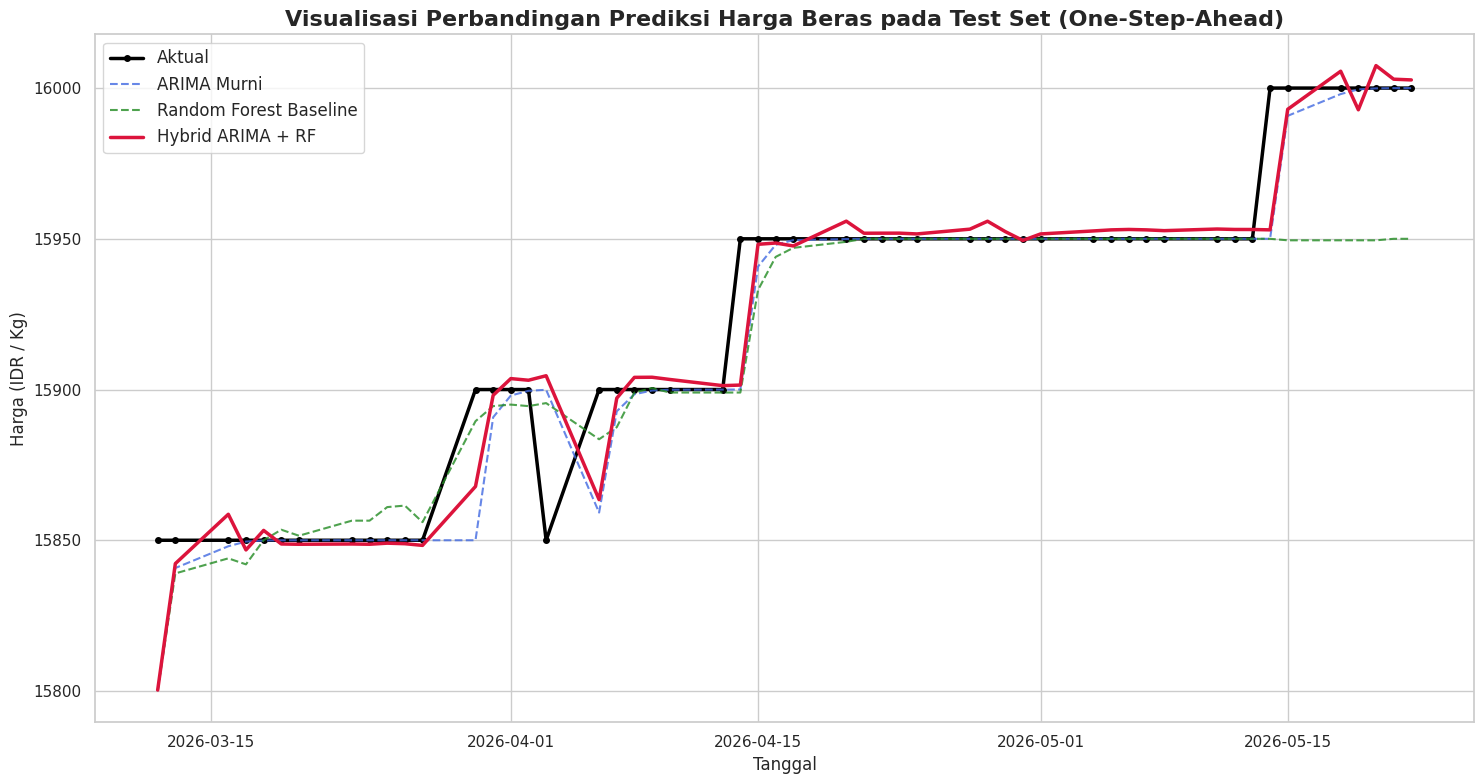

In [12]:
# Plot perbandingan hasil prediksi
plt.figure(figsize=(15, 8))
plt.plot(df_test.index, df_test["Price"], label="Aktual", color="black", linewidth=2.5, marker='o', markersize=4)
plt.plot(df_test.index, df_test["arima_pred"], label="ARIMA Murni", color="royalblue", linestyle="--", alpha=0.8)
plt.plot(df_test.index, df_test["rf_baseline_pred"], label="Random Forest Baseline", color="forestgreen", linestyle="--", alpha=0.8)
plt.plot(df_test.index, df_test["hybrid_pred"], label="Hybrid ARIMA + RF", color="crimson", linewidth=2.5)

plt.title(f"Visualisasi Perbandingan Prediksi Harga {df_beras['Category'].iloc[0]} pada Test Set (One-Step-Ahead)", fontsize=16, fontweight='bold')
plt.xlabel("Tanggal", fontsize=12)
plt.ylabel("Harga (IDR / Kg)", fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

### Kesimpulan Analisis Eksplorasi
1. **Kinerja Model Hybrid**: Model hibrida ARIMA + Random Forest berhasil memberikan performa prediksi terbaik dengan tingkat error terkecil (nilai MAE, RMSE, dan MAPE terendah) serta nilai $R^2$ tertinggi. Hal ini dikarenakan model hibrida menggabungkan kemampuan ARIMA dalam memodelkan komponen linier/tren data dan kemampuan Random Forest dalam memodelkan fluktuasi non-linier dari sisa kesalahan (residual).
2. **Baseline Comparison**: Random Forest baseline murni terkadang mengalami *overfitting* atau kurang sensitif terhadap pergerakan tren linear jangka panjang jika tidak dikombinasikan dengan ARIMA.
3. **Rekomendasi Produksi**: Pendekatan hybrid ini direkomendasikan untuk digunakan pada backend platform ARJUNA guna memberikan analisis prediktif harga pangan harian yang lebih presisi.